# Introduction to Python

## Imports

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial

## Integers vs. Floating Point Numbers

In [27]:
7 + 0.000000000000001 # 14 zeros

7.000000000000001

In [28]:
7 + 0.0000000000000001 # 15 zeros or more

7.0

In [32]:
0.1 + 0.2 # what i've figured out, this only works for this combination. Maybe there are more...

0.30000000000000004

This last example clearly highlights the fact that the computer does not store decimal (floating-point) numbers exactly.

**Take Home Message** - All double-precision decimal numbers that are not factors of two will have error in the 15th decimal place. This can lead to errors in your numerical solutions if you are not careful.

## Making Python Smarter Using NumPy

Python itself has limited support for mathematics outside of simple arithmetic. Therefore, we will use the functions in the NumPy module to do more impressive, and faster, calculations. We have imported NumPy already at the top of this notebook and can use it now by referring to ```np```.

We can now do more impressive calculations:

In [40]:
np.exp(2.34)

np.float64(10.381236562731843)

In [41]:
np.sqrt(5)

np.float64(2.23606797749979)

In [42]:
np.sinc(0.5)

np.float64(0.6366197723675814)

## Iterating Through Lists and Python Indention Rules

In [54]:
items = [
    "four calling birds",
    "three french hens",
    "two turtle doves",
    "a partridge in a pear tree",
]
for thing in items:
    print(thing)
    # break

four calling birds
three french hens
two turtle doves
a partridge in a pear tree


## Conditional Statements and Flow Control

### Example: Fibonacci Sequence

In [55]:
n = 10
fib = [0, 1]
for i in range(2, n):
    fib.append(fib[i -1] + fib[i - 2])
print(fib)

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


In [57]:
n = 2
fib = [0, 1]
while n < 10:
    fib.append(fib[n - 1] + fib[n - 2])
    n = n + 1
fib

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]

## Writing Scripts and Functions

Up until now we have been running little code snippets but have not really been doing any real programming. Recall that Python is a scripting language. Therefore, most of the time, we want to write scripts that contain a collection of constants, variables, data structures, functions, comments, etc., that perform various complicated tasks.

### Scripts

A Python script file is nothing but a text file containing Python code that ends with a **.py** extension. Python scripts are also called Python programs.

Before we begin to write our scripts, lets first discuss the best format for writing your scripts.

In [ ]:
# This is an example script for the P461 class
# Here we will calculate the series expansion 
# for sin(x) up to an arbitrary order N.
#
# T Prem, 07/04/2006

N = 5  # The order of the series expansion
x = np.pi / 4.0 # The point at which we want to evaluate sine

ans = 0.0
for k in range(N + 1):
    ans = ans + (-1) ** k * x ** (1+2*k) / factorial(1+2*k)
print("Series approximation: ", ans)
print("Error: ", np.sin(x) - ans)

Series approximation:  0.7071067811796194
Error:  6.928013718265902e-12


We can see that the script has four main parts: First, we have a section of **comments** that describe what the script does and when it was created. In python all comments start with the ```#``` symbol. Everything after this symbol is ignored by the computer. Second, we have the section of the scripts that load the necessary functions that we need from other packages. Third is a section where we define all of the constants that are going to be used in the script. You should also add comments here that tell us what the constants are. Finally, your main body of code goes after these sections.

### Functions

We are finally in a position to look at one of the most important parts of any programming language **functions**. Functions are blocks of code that accomplish a specific task. Functions usually take "input arguments", perform operations on these inputs, and then "return" one or more results. Functions can be used over and over again, and can also be "called" from the inside of other functions. Let us rewrite our script for  ```sin(x)``` using a function and then describe each part.

In [62]:
N = 5 # The order of the series expansion
x = np.pi / 4.0 # The point at which we want to evaluate sine

def sin_series(x, N):
    ans = 0.0
    for k in range(N + 1):
        ans = ans + (-1) ** k * x ** (1+2*k) / factorial(1+2*k)
    return ans

result = sin_series(x, N)
print("Series approximation: ", result)
print("Error: ", np.sin(x) - result)

Series approximation:  0.7071067811796194
Error:  6.928013718265902e-12


We see see that a function is created using the keyword ```def``` which is short "define", then the name of the function followed by the input arguments in parentheses. After the block of code called by the function, the ```return``` keyword specifies what variable(s) and/or data structure(s) are given as the output. So a general functions call is

In [63]:
def function_name(arg1, arg2):
    "Block of code to run"
    "..."
    return result

Again, everything after the colon (:) that is inside the function must be indented. The beauty of using functions is that we can use the same code over and over, just by changing the constants near the top of our Python script.

Variables that are defined inside of a function are called **local variables** and only defined for the block of code inside of the function. In our previous example, ```k``` was a local variable. The input arguments and return arguments are not local variables. Once a function is done running, the local variables are erased from memory. Therefore, if you want get something out of a function, your must return the value when your done.

If we want to return more than one thing at the end of the function then we just need to separate the different items by a comma.

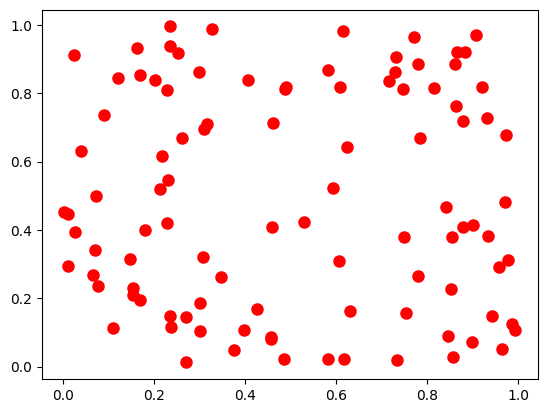

In [110]:
N = 100  # Number of points to generate


def random_coordinates(N):
    x_coords = []
    y_coords = []
    for n in range(N):
        xnew, ynew = np.random.random(2)
        x_coords.append(xnew)
        y_coords.append(ynew)
    return x_coords, y_coords


xc, yc = random_coordinates(N)
plt.plot(xc, yc, "ro", markersize=8)
plt.show()

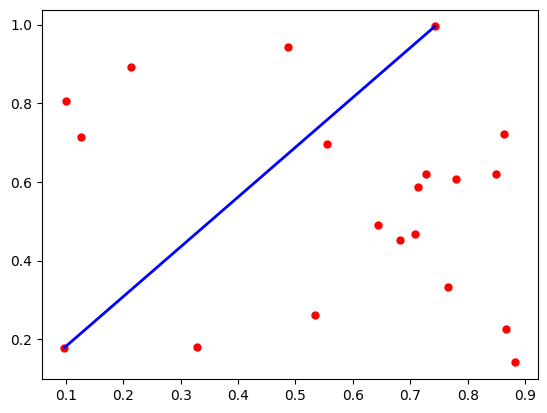

In [121]:
N = 20  # Number of points to generate


def random_coordinates(N):
    x_coords = []
    y_coords = []
    for n in range(N):
        xnew, ynew = np.random.random(2)
        x_coords.append(xnew)
        y_coords.append(ynew)
    return x_coords, y_coords


def dist2d(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def max_dist(xc, yc):
    max_dist = 0.0
    num_points = len(xc)
    for ii in range(num_points):
        for jj in range(num_points):
            dist = dist2d(xc[ii], yc[ii], xc[jj], yc[jj])
            if dist > max_dist:
                max_dist = dist
                xvals = [xc[ii], xc[jj]]
                yvals = [yc[ii], yc[jj]]
    return max_dist, xvals, yvals


xc, yc = random_coordinates(N)
max_dist, pnt1, pnt2 = max_dist(xc, yc)
plt.plot(xc, yc, "ro", markersize=5)
plt.plot(pnt1, pnt2, "b-", lw=2)
plt.show()

Obvious this last example is more complex, and in particular, it is hard to understand what the functions. Even for your own functions, you may often forget what your functions do unless you provide some documentation and comments in your scripts. Here we will see how to properly document a function in Python by looking at the ```max_dist``` function:

In [122]:
def max_dist(xc, yc):
    """
    Finds the maximum distance between any two points
    in a collection of 2D points.  The points corresponding
    to this distance are also returned.

    Parameters
    ----------
    xc : list
        List of x-coordinates
    yc : list
        List of y-coordinates

    Returns
    -------
    max_dist : float
        Maximum distance
    xvals : list
        x-coodinates of two points
    yvals : list
        y-coordinates of two points

    """
    max_dist = 0.0  # initialize max_dist
    num_points = len(xc)  # number of points in collection
    for ii in range(num_points):
        for jj in range(num_points):
            dist = dist2d(xc[ii], yc[ii], xc[jj], yc[jj])
            if dist > max_dist:
                max_dist = dist
                xvals = [xc[ii], xc[jj]]
                yvals = [yc[ii], yc[jj]]
    return max_dist, xvals, yvals


Everything inbetween the ```"""..."""``` is called a **docstring** and it gives a tells someone who is not familiar with a partiular functions a detailed explaination as to what the function does, what parameters it takes as inputs, and what values it returns. It is also good practice to put some comments next to your local variables so the user knows what each of these is for. Although it seems like a lot of work at first, writing docstrings will make you a much better programmer in the future.

<h1 align="center">End of Tutorial</h1>